#**Building a CNN Model for Intel Image Classification**

**The goal of this assignment is to design, implement, and evaluate a Convolutional Neural
Network (CNN) model using a real-world dataset. Students will gain hands-on experience in
data preprocessing, CNN architecture design, training, evaluation, and model interpretation.**

### Import Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import random


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

## Upload Dataset From Kaggle

In [4]:
import json

kaggle_config = {
    "username": "suhaila zubair",
    "key": "KGAT_8aa49785d1bf6005378a7c1bb8e6228f"
}

with open("kaggle_config.json", "w") as f:
    json.dump(kaggle_config, f)

print("Kaggle.json  file created successfully.")

Kaggle.json  file created successfully.


In [5]:
!mkdir -p ~/.kaggle
!cp kaggle_config.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle_config.json

In [6]:
!pip install -q --upgrade kaggle

###Load & Explore The Dataset

loads the dataset explore the dataset structure.It helps training, validation and testing data.

In [7]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
intel-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
!unzip -oq intel-image-classification.zip
print("Dataset unzipped successfully.")

Dataset unzipped successfully.


In [9]:
print(os.listdir())

['.config', 'seg_pred', 'intel-image-classification.zip', 'seg_test', 'best_model.keras', 'seg_train', 'kaggle_config.json', 'sample_data']


In [10]:
train_path ="/content/seg_train/seg_train"
test_path ="/content/seg_test/seg_test"

classes = os.listdir(train_path)
print("Classes:-",classes)

print("Number of classes:-", len(classes))

Classes:- ['sea', 'buildings', 'glacier', 'street', 'forest', 'mountain']
Number of classes:- 6


displaying images

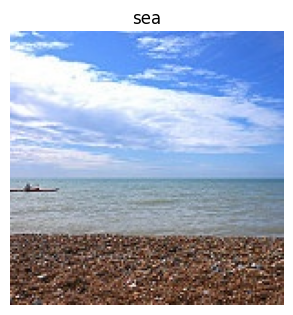

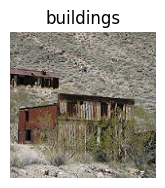

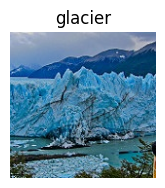

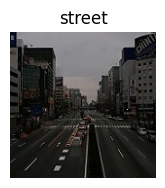

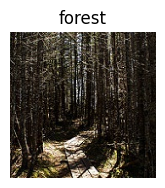

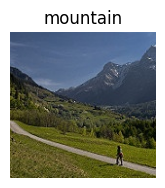

In [11]:
plt.figure(figsize=(12,8))

for i, category in enumerate(classes):
  image_name =os.listdir(os.path.join(train_path, category))[0]

  image = plt.imread(os.path.join(train_path, category, image_name))

  plt.subplot(2,3,i+1)
  plt.imshow(image)
  plt.title(category)
  plt.axis("off")

  plt.show()

Data Augmentation

In [12]:
image_size = (150,150)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

Creating train and validation sets

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## Build the CNN Model
In this section defines the covolutional neural network(CNN) architecture used for image classification.

In [14]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D(2,2))

# Second Convolution Layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Third Convolution Layer
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(6,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##Compile Model
 In this cell compiles the CNN model by defining the optimizer, loss func, and evaluation metrics

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

## Train the CNN Model
In this section trains the CNN model using the prepared training dataset and validates its performance on validation data

 Early Stopping

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True
)

 Train Model

In [17]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 649s 2s/step - accuracy: 0.4960 - loss: 1.2340 - val_accuracy: 0.5867 - val_loss: 1.0524
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.6031 - loss: 1.0173 - val_accuracy: 0.6969 - val_loss: 0.8390
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 645s 2s/step - accuracy: 0.6621 - loss: 0.9033 - val_accuracy: 0.7093 - val_loss: 0.7752
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 646s 2s/step - accuracy: 0.6883 - loss: 0.8397 - val_accuracy: 0.7072 - val_loss: 0.7768
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 648s 2s/step - accuracy: 0.7079 - loss: 0.7933 - val_accuracy: 0.7461 - val_loss: 0.6771
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 672s 2s/step - accuracy: 0.7205 - loss: 0.7593 - val_accuracy: 0.7529 - val_loss: 0.6867
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - accuracy: 0.7405 - loss: 0.7212 - val_accuracy: 0.7436 - val_loss: 0.7053
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.7495 - loss: 0.7011 - val_accu

## Plot Accuracy and Loss Curves

##visualize Sample images
In this section visualizes images from the dataset to better understand the image classes, dimensions and variations in the data.

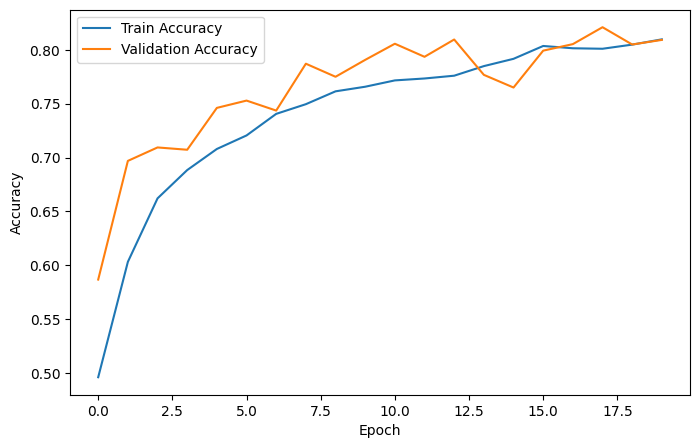

In [18]:
#Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

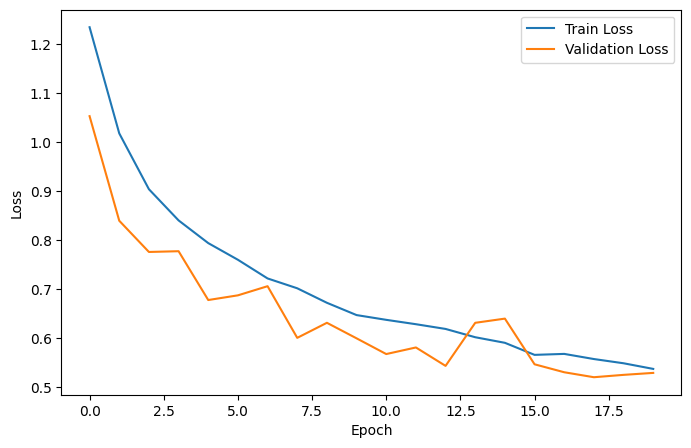

In [19]:
#loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

##MODEL EVALUATION
in this cell evaluates the trained CNN model on the test dataset to measure its accuracy and loss.

Test Accuracy

In [20]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 43s 451ms/step - accuracy: 0.8503 - loss: 0.4468
Test Accuracy: 0.8503333330154419


#Classification Report
In this section uses the trained model to generates predictions for unseen images or test samples.

In [21]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions,axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 42s 447ms/step
              precision    recall  f1-score   support

   buildings       0.76      0.89      0.82       437
      forest       0.96      0.97      0.97       474
     glacier       0.83      0.82      0.82       553
    mountain       0.84      0.73      0.78       525
         sea       0.87      0.83      0.85       510
      street       0.85      0.88      0.86       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



Confusion Matrix

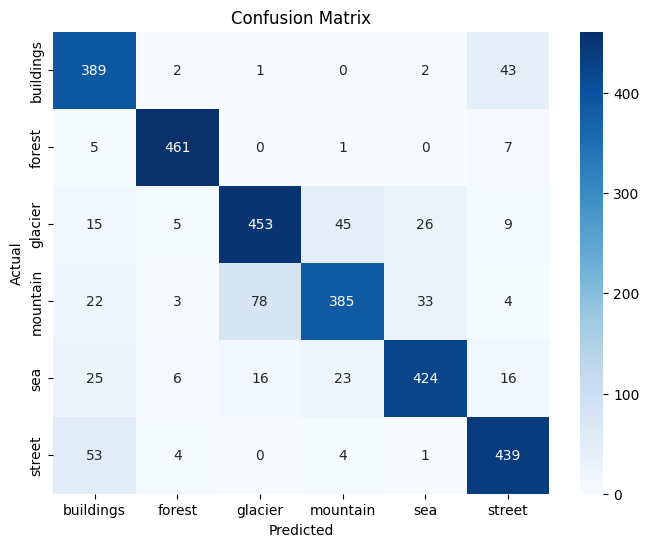

In [22]:
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#Visualize predictions for 10 Test Images
At this cell loads the dataset paths and expplores the dataset structure. it helps verify that the training, validation, and testing data are correctly organized.

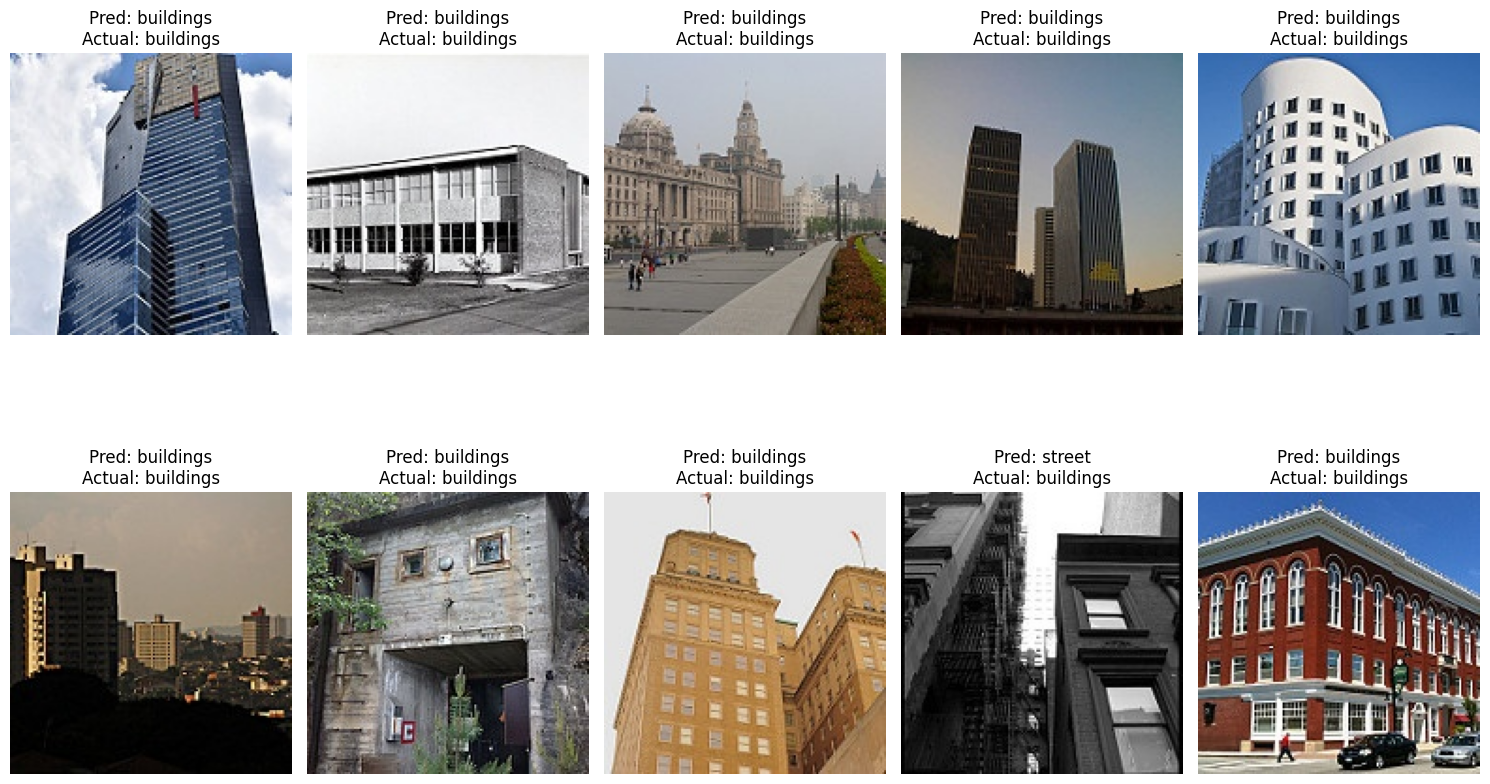

In [23]:
plt.figure(figsize=(15,10))

for i in range(10):

    img, label = test_generator[i]

    image = img[0]
    true_label = class_names[np.argmax(label[0])]

    prediction = model.predict(np.expand_dims(image,axis=0),verbose=0)
    pred_label = class_names[np.argmax(prediction)]

    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(f"Pred: {pred_label}\nActual: {true_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()